In [2]:
import rasterio
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import os

In [3]:
month = 3
year = '2026'

dataset = 'temperature'
local_dep_dir = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/scripts/data/dependencies"
output_dir = "/Users/cherryleheu/Documents/dews-hawaii/dews-hawaii-app/public"
climo_file = os.path.join(local_dep_dir, f"climo/{dataset}/{dataset}_1991-2020_{month:02d}.tif")
with rasterio.open(climo_file) as src:
    temp_climo = src.read(1)
    nodata_climo = src.nodata
    meta = src.meta.copy()

masked_climo = np.ma.masked_equal(temp_climo, nodata_climo)

raster_dir = os.path.join(local_dep_dir, dataset, f"{dataset}_{year}_{month:02d}.tif")
with rasterio.open(raster_dir) as src:
    temp = src.read(1)
    nodata_temp = src.nodata
    transform = src.transform

masked_temp= np.ma.masked_equal(temp, nodata_temp)

diff = (masked_temp - masked_climo)

combined_mask = np.ma.getmask(masked_temp) | np.ma.getmask(masked_climo)
pdiff_masked = np.ma.array(diff, mask=combined_mask)

out_nodata = -9999 
meta.update(
    dtype="float32",
    nodata=out_nodata
)

with rasterio.open(f"../public/tifs/tmean_diff_{year}_{month:02d}.tif", "w", **meta) as dst:
    dst.write(pdiff_masked.filled(out_nodata).astype("float32"), 1)


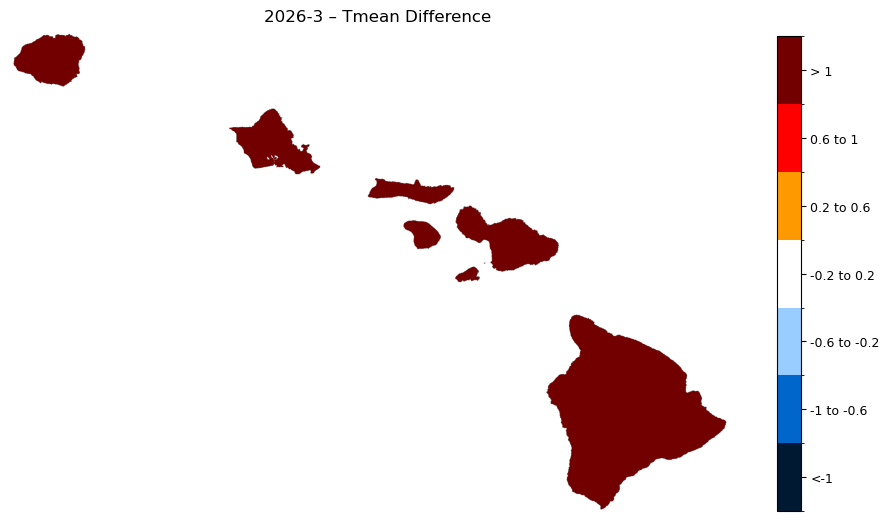

In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

thresholds = [
    (-np.inf, -1, "#001933", "<-1"),
    (-1, -0.6, "#0066CC", "-1 to -0.6"),
    (-0.6, -0.2, "#99CCFF", "-0.6 to -0.2"),
    (-0.2, 0.2, "#FFFFFF", "-0.2 to 0.2"),
    (0.2, 0.6, "#FF9900", "0.2 to 0.6"),
    (0.6, 1, "#FF0000", "0.6 to 1"),
    (1, np.inf, "#730000", "> 1"),
]

with rasterio.open(raster_dir) as src:
    data = src.read(1)
    profile = src.profile
    nodata = src.nodata

data = np.where(data == nodata, np.nan, data)
categorical = np.full_like(data, 255, dtype=np.uint8)

for i, (low, high, _, _) in enumerate(thresholds):
    mask = (data > low) & (data <= high)
    categorical[mask] = i

profile.update(dtype=rasterio.uint8, count=1, compress='lzw', nodata=255)
with rasterio.open("../public/tifs/temperature_diff_cat.tif", "w", **profile) as dst:
    dst.write(categorical, 1)

colors = [c for _, _, c, _ in thresholds]
labels = [l for _, _, _, l in thresholds]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(colors) + 0.5), len(colors))

plt.figure(figsize=(9, 6))
categorical_masked = np.ma.masked_where(categorical == 255, categorical)

im = plt.imshow(categorical_masked, cmap=cmap, norm=norm)
plt.axis("off")

cbar = plt.colorbar(im, fraction=0.03, pad=0.04)
cbar.set_ticks(range(len(colors)))
cbar.set_ticklabels(labels)
cbar.ax.tick_params(labelsize=9)
plt.title(f"{year}-{month} – Tmean Difference")
plt.tight_layout()
plt.show()
